# Prediciendo los precios de las casas

### 1. Analizar la calidad de datos, para lo que debes cargarlos y realizar un proceso exhaustivo de limpieza para eliminar valores faltantes, duplicados y atípicos que puedan afectar la calidad del modelo, si los hay.



In [1]:
# importar librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.tree import plot_tree
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, train_test_split, cross_val_score
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.linear_model import Ridge, Lasso, ElasticNet

from IPython.display import display

# Cargamos el dataset
df = pd.read_excel("house_data.xlsx")

### Funcion para el análisis del dataset 

In [2]:
# Análisis general del dataset
def analisis_general(df):                                       # Función para realizar un análisis general del dataset
    print("ANÁLISIS GENERAL DEL DATASET\n")                     # Título del análisis
    
    # vista inicial
    print("Primeros registros:")                                # Mostrar las primeras filas del dataset
    display(df.head())                                          # Mostrar las primeras filas del dataset 

    # Tabla resumen de calidad (CLAVE)
    resumen = pd.DataFrame({                                    # Crear un DataFrame para resumir la calidad de los datos
        "Tipo de dato": df.dtypes,                              # Tipo de dato de cada columna
        "Nulos": df.isnull().sum(),                             # Cantidad de valores nulos en cada columna
        "% Nulos": (df.isnull().mean() * 100).round(2),         # Porcentaje de valores nulos en cada columna
        "Valores únicos": df.nunique()                          # Cantidad de valores únicos en cada columna
    }).sort_values(by="% Nulos", ascending=False)               # Ordenar el resumen por porcentaje de valores nulos de mayor a menor
    
    print("\nResumen de calidad de datos:")                     # Mostrar el resumen de calidad de los datos
    display(resumen)                                            # Mostrar el resumen de calidad de los datos

    # Duplicados
    print("\nDuplicados:", df.duplicated().sum())               # Mostrar la cantidad de filas duplicadas en el dataset

    # Estadísticas descriptivas (solo numéricas, más limpio)
    print("\nEstadísticas descriptivas:")                       # Mostrar las estadísticas descriptivas de las columnas numéricas del dataset
    display(df.describe())                                      # Mostrar las estadísticas descriptivas de las columnas numéricas del dataset

In [3]:
# Ejecutamos el análisis general
analisis_general(df)    # Llamar a la función para realizar el análisis general del dataset

ANÁLISIS GENERAL DEL DATASET

Primeros registros:


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503



Resumen de calidad de datos:


,Tipo de dato,Nulos,% Nulos,Valores únicos
id,int64,0,0.0,21436
date,object,0,0.0,372
price,int64,0,0.0,4028
bedrooms,int64,0,0.0,13
bathrooms,float64,0,0.0,30
sqft_living,int64,0,0.0,1038
sqft_lot,int64,0,0.0,9782
floors,float64,0,0.0,6
waterfront,int64,0,0.0,2
view,int64,0,0.0,5



Duplicados: 0

Estadísticas descriptivas:


,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,4.580302e+09,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,2.876566e+09,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


El dataset contiene 21.613 registros y 21 variables, sin presencia de valores nulos ni duplicados. La mayoría de las variables son numéricas, lo que facilita el análisis. Se identificó que la variable date requiere transformación a formato adecuado para su uso en el modelo.

In [4]:
# Función para realizar la limpieza inicial del dataset
def limpieza_inicial(df):                                                               # Función para realizar la limpieza inicial del dataset
    df = df.copy()                                                                      # Crear una copia del DataFrame para evitar modificar el original

    print("DIMENSIÓN INICIAL:", df.shape)                                               # Mostrar la dimensión inicial del dataset                              

    #Transformar date a fecha
    df["date"] = pd.to_datetime(df["date"], format="%Y%m%dT000000", errors="coerce")    # Convertir la columna "date" a formato datetime, especificando el formato y manejando errores con "coerce"
    
    # Creamos variables temporales a partir de la fecha
    df["year_sale"] = df["date"].dt.year                                                # Extraer el año de la columna "date" y crear una nueva columna "year_sale"  
    df["month_sale"] = df["date"].dt.month                                              # Extraer el mes de la columna "date" y crear una nueva columna "month_sale"                            
    
    # Eliminar columnas que no aportan al modelo
    df = df.drop(columns=["id", "date"], errors="ignore")                               # Eliminar las columnas "id" y "date" del DataFrame, ignorando errores si no existen
    
    print("\nDIMENSIÓN FINAL:", df.shape)                                               # Mostrar la dimensión final del dataset después de la limpieza
    return df                                                                           # Devolver el DataFrame limpio

In [5]:
# Ejecutamos la limpieza inicial
df_limpio = limpieza_inicial(df)    # Llamar a la función para realizar la limpieza inicial del dataset y almacenar el resultado en df_limpio
display(df_limpio.head())           # Mostrar las primeras filas del DataFrame limpio

DIMENSIÓN INICIAL: (21613, 21)

DIMENSIÓN FINAL: (21613, 21)


,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,year_sale,month_sale
0,221900,3,1.00,1180,5650,1.0,0,0,3,7,...,0,1955,0,98178,47.5112,-122.257,1340,5650,2014,10
1,538000,3,2.25,2570,7242,2.0,0,0,3,7,...,400,1951,1991,98125,47.7210,-122.319,1690,7639,2014,12
2,180000,2,1.00,770,10000,1.0,0,0,3,6,...,0,1933,0,98028,47.7379,-122.233,2720,8062,2015,2
3,604000,4,3.00,1960,5000,1.0,0,0,5,7,...,910,1965,0,98136,47.5208,-122.393,1360,5000,2014,12
4,510000,3,2.00,1680,8080,1.0,0,0,3,8,...,0,1987,0,98074,47.6168,-122.045,1800,7503,2015,2


Se transformó la variable date en nuevas variables temporales (year_sale y month_sale) para facilitar su interpretación. Además, se eliminaron variables no relevantes como identificadores, asegurando que el dataset esté preparado para el análisis y modelado.

In [6]:
# Función para detectar outliers utilizando el método del IQR
def detectar_outliers_iqr(df):                                          # Función para detectar outliers utilizando el método del IQR
    columnas_numericas = df.select_dtypes(include=[np.number]).columns  # Seleccionar solo las columnas numéricas del DataFrame
    outliers = {}                                                       # Diccionario para almacenar la cantidad de outliers por columna

    for col in columnas_numericas:                                      # Iterar sobre cada columna numérica
        Q1 = df[col].quantile(0.25)                                     # Calcular el primer cuartil (Q1) de la columna
        Q3 = df[col].quantile(0.75)                                     # Calcular el tercer cuartil (Q3) de la columna
        IQR = Q3 - Q1                                                   # Calcular el rango intercuartílico (IQR) de la columna                                
        lower = Q1 - 1.5 * IQR                                          # Calcular el límite inferior para detectar outliers
        upper = Q3 + 1.5 * IQR                                          # Calcular el límite superior para detectar outliers

        n_outliers = df[(df[col] < lower) | (df[col] > upper)].shape[0] # Contar la cantidad de outliers en la columna
        outliers[col] = n_outliers                                      # Almacenar la cantidad de outliers en el diccionario

    return pd.Series(outliers).sort_values(ascending=False)             # Devolver una Serie con la cantidad de outliers por columna, ordenada de mayor a menor

In [7]:
# Detectamos outliers utilizando el método del IQR
outliers_resumen = detectar_outliers_iqr(df_limpio)                             # Llamar a la función para detectar outliers utilizando el método del IQR y almacenar el resultado en outliers_resumen
outliers_df = pd.DataFrame(outliers_resumen, columns=["Cantidad de outliers"])  # Crear un DataFrame a partir de la Serie de outliers para mostrar la cantidad de outliers por columna
display(outliers_df)                                                            # Mostrar el DataFrame con la cantidad de outliers por columna

,Cantidad de outliers
sqft_lot,2425
sqft_lot15,2194
view,2124
grade,1911
price,1146
yr_renovated,914
sqft_above,611
sqft_living,572
bathrooms,571
bedrooms,546


Se detectó una alta cantidad de valores atípicos en variables como sqft_lot, sqft_living y price, lo cual es esperable en datos del mercado inmobiliario debido a la variabilidad en tamaño y valor de las propiedades.

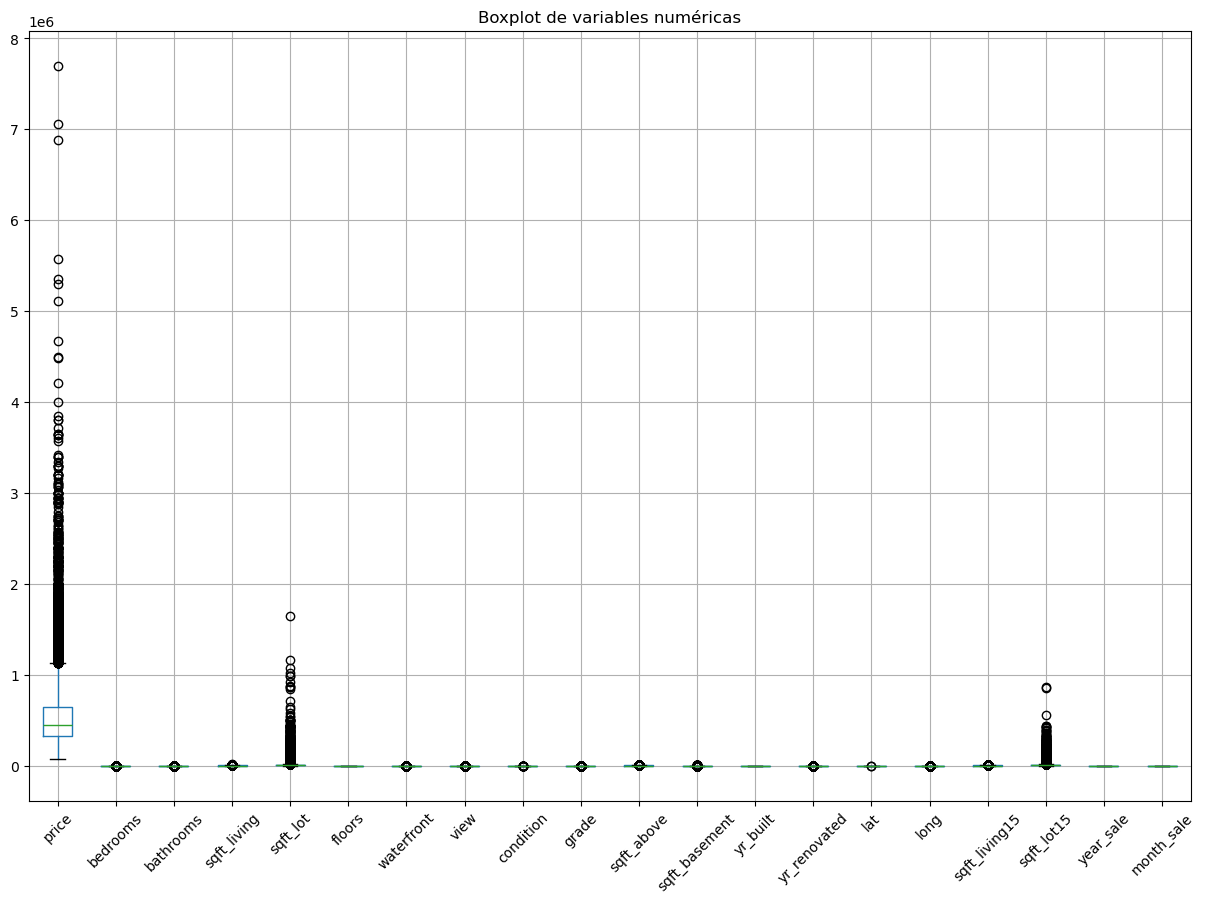

In [8]:
# Excluir variables poco útiles para visualización
columnas_numericas = df_limpio.select_dtypes(include=[np.number]).columns   # Seleccionar solo las columnas numéricas del DataFrame
cols_plot = [col for col in columnas_numericas if col not in ["zipcode"]]   # Excluir la columna "zipcode" de las columnas numéricas para la visualización

plt.figure(figsize=(15, 10))                                                # Configurar el tamaño de la figura para la visualización
df_limpio[cols_plot].boxplot(rot=45)                                        # Crear un boxplot para las columnas numéricas seleccionadas, rotando las etiquetas del eje x para mejor legibilidad    
plt.title("Boxplot de variables numéricas")                                 # Agregar un título a la visualización
plt.show()                                                                  # Mostrar la visualización del boxplot para detectar outliers en las variables numéricas seleccionadas

Los diagramas de caja y bigotes evidenciaron la presencia de valores extremos y distribuciones asimétricas. Sin embargo, la visualización inicial se vio afectada por diferencias de escala entre variables.

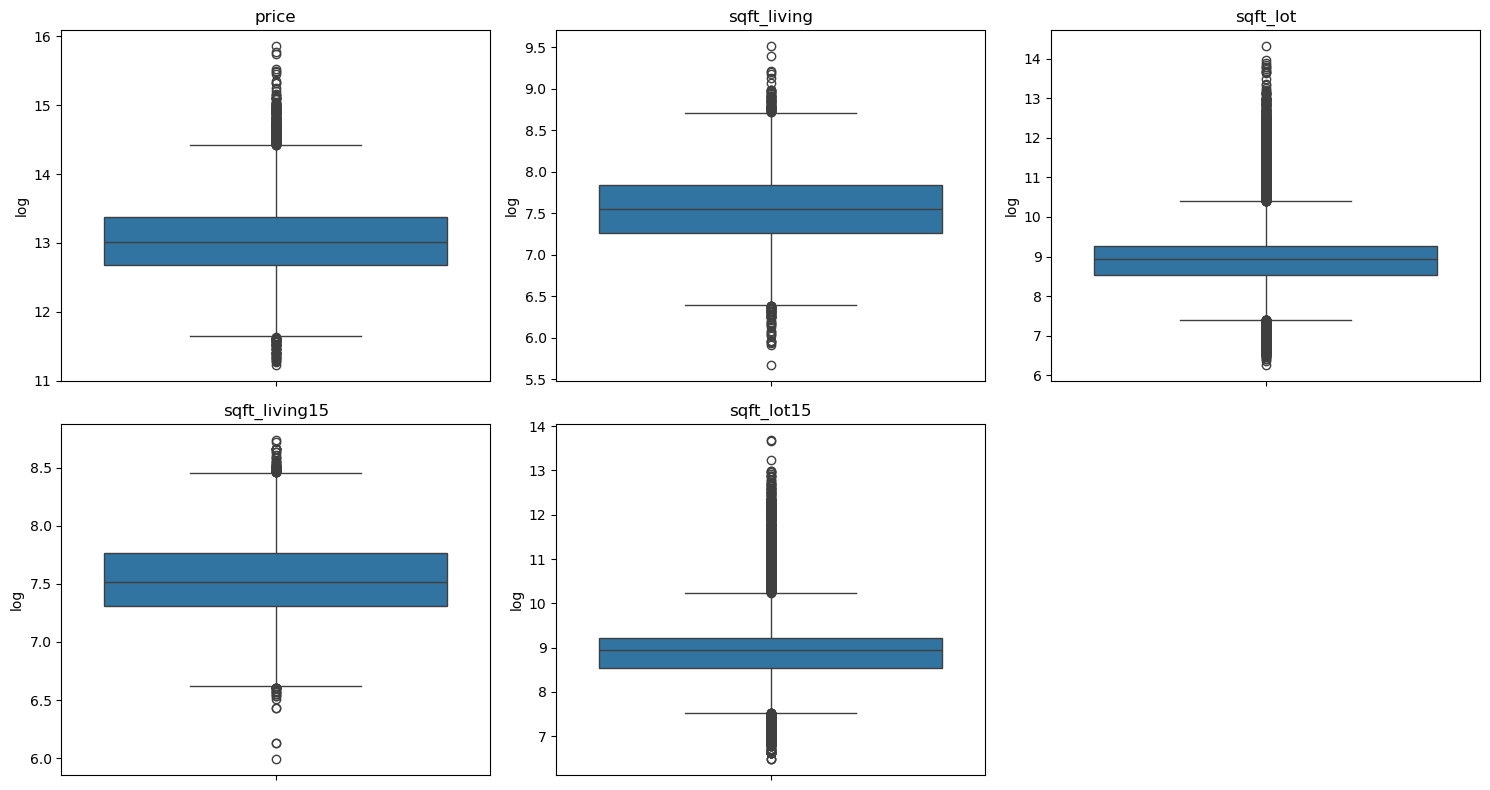

In [9]:
# Visualización de outliers utilizando boxplot con escala logarítmica para las variables más importantes
cols_importantes = [                                    # Seleccionar las columnas más importantes para la visualización de outliers con escala logarítmica
    'price',                                            # La variable objetivo "price" es una de las más importantes para analizar su distribución y detectar outliers
    'sqft_living',                                      # La variable "sqft_living" es importante para analizar su relación con el precio y detectar outliers en su distribución
    'sqft_lot',                                         # La variable "sqft_lot" es importante para analizar su relación con el precio y detectar outliers en su distribución
    'sqft_living15',                                    # La variable "sqft_living15" es importante para analizar su relación con el precio y detectar outliers en su distribución
    'sqft_lot15'                                        # La variable "sqft_lot15" es importante para analizar su relación con el precio y detectar outliers en su distribución
]

# Crear grilla
n_cols = 3                                              # Número de columnas para la grilla de visualización
n_rows = int(np.ceil(len(cols_importantes) / n_cols))   # Calcular el número de filas necesarias para la grilla de visualización en función de la cantidad de columnas importantes y el número de columnas por fila

plt.figure(figsize=(15, 8))                             # Configurar el tamaño de la figura para la visualización

for i, col in enumerate(cols_importantes):              # Iterar sobre cada columna importante para crear un boxplot con escala logarítmica
    plt.subplot(n_rows, n_cols, i + 1)                  # Crear un subplot para cada columna importante en la grilla de visualización
    
    data_log = np.log1p(df_limpio[col])                 # Aplicar la transformación logarítmica a los datos de la columna para mejorar la visualización de outliers
    sns.boxplot(y=data_log)                             # Crear un boxplot para la columna transformada logarítmicamente utilizando seaborn
    
    plt.title(col)                                      # Agregar un título a cada subplot con el nombre de la columna
    plt.ylabel("log")                                   # Etiqueta del eje y para indicar que los datos están en escala logarítmica

plt.tight_layout()                                      # Ajustar el diseño de la figura para evitar solapamientos entre los subplots
plt.show()                                              # Mostrar la visualización de los boxplots con escala logarítmica para las columnas importantes

Se aplicó una transformación logarítmica para mejorar la visualización de las variables con alta dispersión. Esto permitió observar con mayor claridad la distribución de los datos y reducir el impacto visual de los valores extremos.

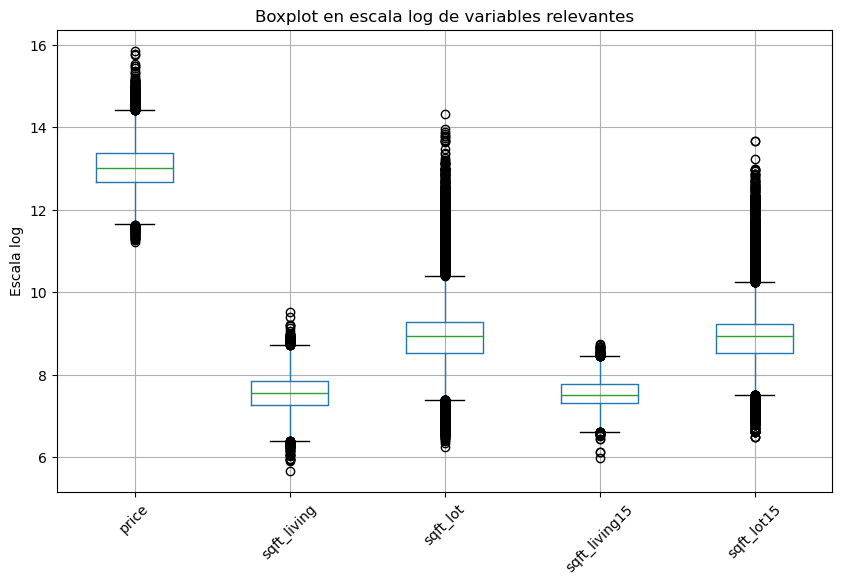

In [10]:
# Alternativamente, podemos aplicar la transformación logarítmica a las columnas importantes y luego crear un boxplot para todas ellas en una sola visualización
df_log = df_limpio[cols_importantes].apply(np.log1p)        # Aplicar la transformación logarítmica a las columnas importantes del DataFrame para mejorar la visualización de outliers en un solo boxplot

plt.figure(figsize=(10,6))                                  # Configurar el tamaño de la figura para la visualización   
df_log.boxplot(rot=45)                                      # Crear un boxplot para las columnas transformadas logarítmicamente, rotando las etiquetas del eje x para mejor legibilidad
plt.title("Boxplot en escala log de variables relevantes")  # Agregar un título a la visualización del boxplot para las columnas importantes en escala logarítmica
plt.ylabel("Escala log")                                    # Etiqueta del eje y para indicar que los datos están en escala logarítmica
plt.show()                                                  # Mostrar la visualización del boxplot para las columnas importantes en escala logarítmica

Se realizó un análisis exhaustivo de la calidad de los datos, verificando la ausencia de valores nulos y registros duplicados. Posteriormente, se llevó a cabo la detección de valores atípicos utilizando el método del rango intercuartílico (IQR), identificando una alta presencia de outliers en variables como sqft_lot, sqft_living y price.

Para una mejor visualización, se utilizaron diagramas de caja y bigotes (boxplots), observándose inicialmente problemas de escala debido a la gran dispersión de los datos. Para solucionar esto, se aplicó una transformación logarítmica a las variables más relevantes, permitiendo una representación más clara de la distribución.

Se concluye que los valores atípicos corresponden a características propias del mercado inmobiliario (como propiedades de gran tamaño o alto valor), por lo que no se consideran errores y se mantienen para el modelado posterior.

### 2. Realizar un análisis descriptivo de las variables para entender la distribución de los datos y detectar posibles relaciones entre las características y los precios. En esto debes incluir un análisis de correlaciones entre las variables principalmente con el precio de las casas, comenta acerca de las variables con mayor correlación, ¿tienen sentido?




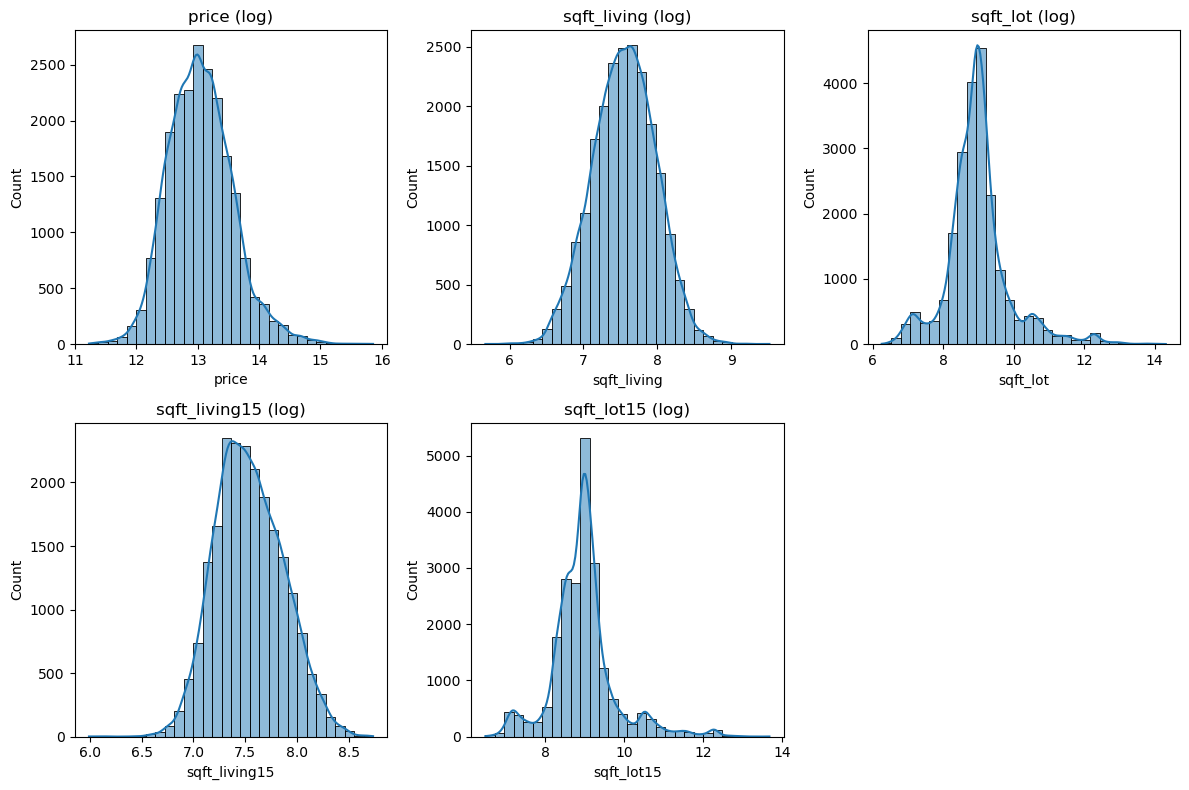

In [11]:
# Visualización de histogramas con escala logarítmica para las variables más importantes
plt.figure(figsize=(12,8))                                      # Configurar el tamaño de la figura para la visualización      

for i, col in enumerate(cols_importantes):                      # Iterar sobre cada columna importante para crear un histograma con escala logarítmica
    plt.subplot(2, 3, i + 1)                                    # Crear un subplot para cada columna importante en una grilla de 2 filas y 3 columnas
    sns.histplot(np.log1p(df_limpio[col]), bins=30, kde=True)   # Crear un histograma para la columna transformada logarítmicamente utilizando seaborn, con 30 bins y una curva KDE para visualizar la distribución de los datos
    plt.title(f"{col} (log)")                                   # Agregar un título a cada subplot con el nombre de la columna y la indicación de que está en escala logarítmica

plt.tight_layout()                                              # Ajustar el diseño de la figura para evitar solapamientos entre los subplots
plt.show()                                                      # Mostrar la visualización de los histogramas con escala logarítmica para las columnas importantes

Se analizaron las distribuciones de las variables más relevantes utilizando histogramas. Inicialmente, las variables presentaban una fuerte asimetría, especialmente en aquellas relacionadas con tamaño y precio.

Para mejorar la interpretación, se aplicó una transformación logarítmica, logrando distribuciones más simétricas y facilitando el análisis visual. Esto permite comprender mejor el comportamiento de las variables y su posible relación con el precio de las viviendas.

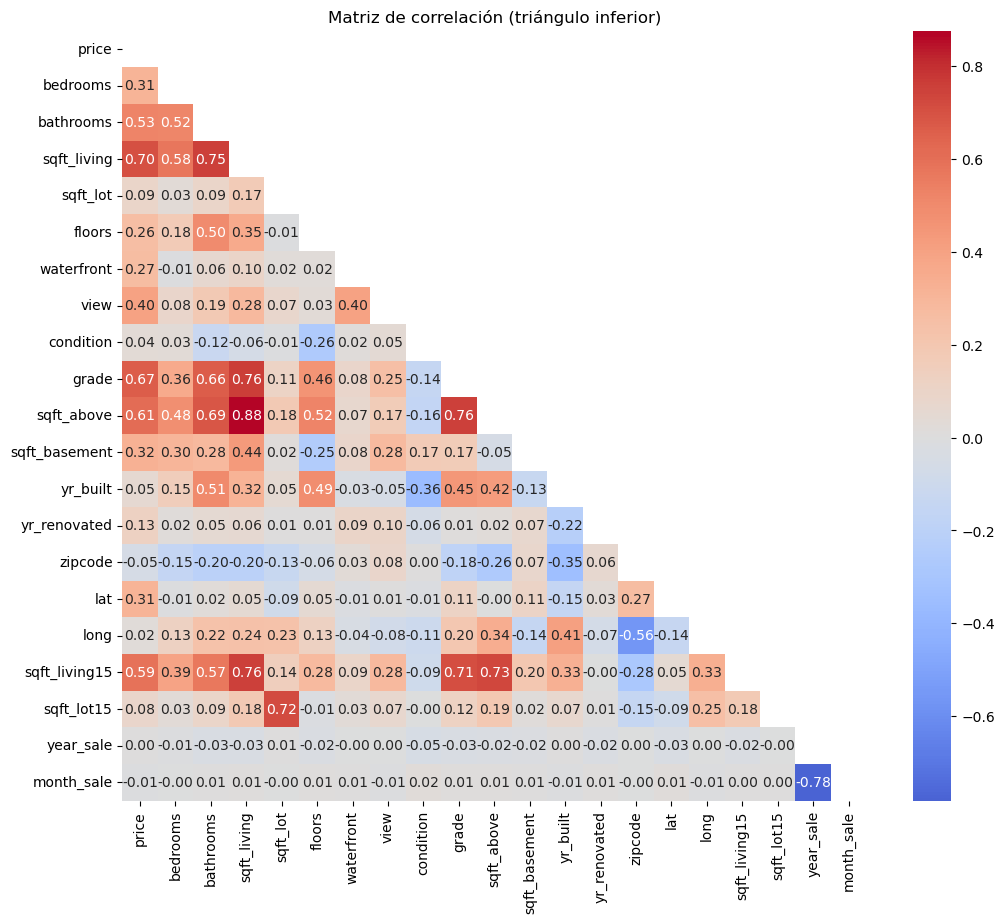

In [12]:
# Matriz de correlación (triángulo inferior)
corr = df_limpio.corr()                                 # Calcular la matriz de correlación para las columnas numéricas del DataFrame limpio   
mask = np.triu(np.ones_like(corr, dtype=bool))          # Crear una máscara para ocultar el triángulo superior de la matriz de correlación, dejando visible solo el triángulo inferior

plt.figure(figsize=(12,10))                             # Configurar el tamaño de la figura para la visualización

sns.heatmap(                                            # Crear un heatmap para visualizar la matriz de correlación utilizando seaborn, aplicando la máscara para mostrar solo el triángulo inferior y utilizando una paleta de colores "coolwarm" centrada en 0, con anotaciones de los valores de correlación formateados a 2 decimales
    corr,                                               # La matriz de correlación calculada previamente para las columnas numéricas del DataFrame limpio
    mask=mask,                                          # La máscara para ocultar el triángulo superior de la matriz de correlación
    cmap='coolwarm',                                    # La paleta de colores "coolwarm" es una opción común para visualizar matrices de correlación, donde los colores cálidos representan correlaciones positivas y los colores fríos representan correlaciones negativas
    center=0,                                           # Centrar la paleta de colores en 0 para que las correlaciones positivas y negativas se visualicen de manera equilibrada
    annot=True,                                         # Mostrar los valores de correlación en cada celda del heatmap
    fmt=".2f"                                           # Formatear los valores de correlación a 2 decimales para una mejor legibilidad en el heatmap
)

plt.title("Matriz de correlación (triángulo inferior)") # Agregar un título a la visualización del heatmap de la matriz de correlación
plt.show()                                              # Mostrar la visualización del heatmap de la matriz de correlación

La matriz de correlación muestra que variables como sqft_living, grade, sqft_above y sqft_living15 presentan una alta correlación positiva con el precio, lo que indica que el tamaño y la calidad de la propiedad son factores clave en su valor.

También se observa la existencia de multicolinealidad entre variables relacionadas con superficie, lo que sugiere redundancia en la información. Por otro lado, variables como zipcode, condition y las variables temporales presentan baja correlación con el precio, indicando un impacto limitado en la predicción.

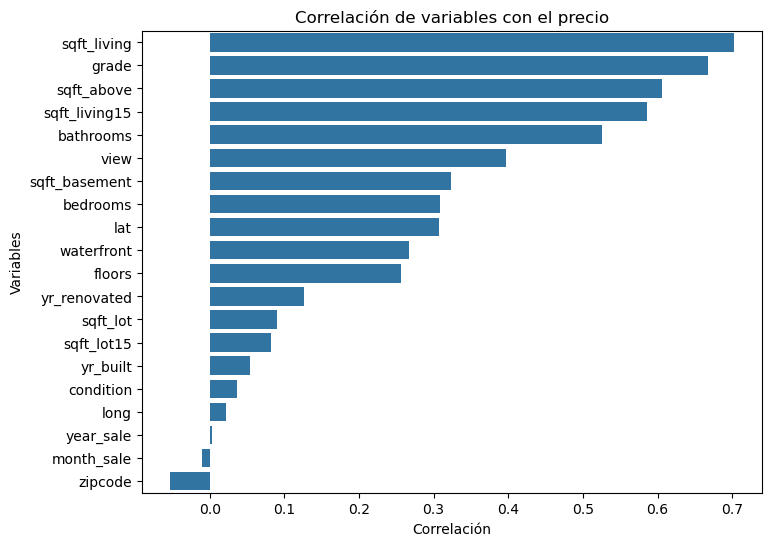

In [13]:
# Visualización de la correlación de variables con el precio utilizando un gráfico de barras
corr_price = df_limpio.corr()[['price']].drop('price').sort_values(by='price', ascending=False) # Calcular la correlación de todas las variables con la variable objetivo "price", eliminar la fila correspondiente a "price" para no mostrar la autocorrelación y ordenar los resultados por el valor de correlación de mayor a menor
plt.figure(figsize=(8,6))                                                                       # Configurar el tamaño de la figura para la visualización                                  
sns.barplot(x=corr_price['price'].values, y=corr_price.index)                                   # Crear un gráfico de barras para visualizar la correlación de cada variable con el precio, utilizando seaborn y ordenando las barras según el valor de correlación
plt.title("Correlación de variables con el precio")                                             # Agregar un título a la visualización del gráfico de barras para la correlación de variables con el precio
plt.xlabel("Correlación")                                                                       # Etiqueta del eje x para indicar que los valores representan la correlación de cada variable con el precio
plt.ylabel("Variables")                                                                         # Etiqueta del eje y para indicar que las categorías representan las variables del dataset
plt.show()                                                                                      # Mostrar la visualización del gráfico de barras para la correlación de variables con el precio

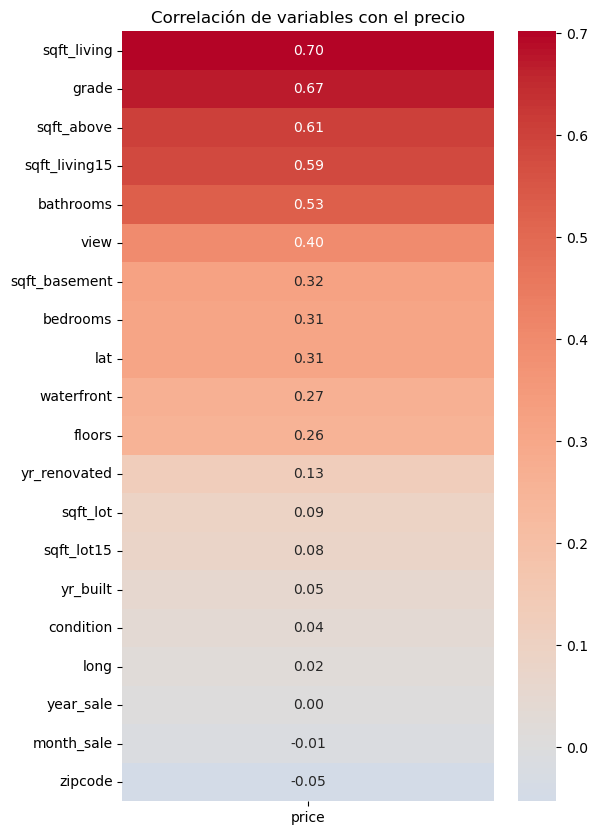

In [14]:
# Visualización de la correlación de variables con el precio utilizando un heatmap
plt.figure(figsize=(6,10))                          # Configurar el tamaño de la figura para la visualización     
sns.heatmap(                                        # Crear un heatmap para visualizar la correlación de cada variable con el precio utilizando seaborn, con una paleta de colores "coolwarm" centrada en 0, y anotaciones de los valores de correlación formateados a 2 decimales
    corr_price,                                     # La matriz de correlación de cada variable con el precio calculada previamente
    annot=True,                                     # Mostrar los valores de correlación en cada celda del heatmap
    cmap='coolwarm',                                # La paleta de colores "coolwarm" es una opción común para visualizar matrices de correlación, donde los colores cálidos representan correlaciones positivas y los colores fríos representan correlaciones negativas
    center=0,                                       # Centrar la paleta de colores en 0 para que las correlaciones positivas y negativas se visualicen de manera equilibrada
    fmt=".2f"                                       # Formatear los valores de correlación a 2 decimales para una mejor legibilidad en el heatmap
)

plt.title("Correlación de variables con el precio") # Agregar un título a la visualización del heatmap de la correlación de variables con el precio
plt.show()                                          # Mostrar la visualización del heatmap de la correlación de variables con el precio

Se calculó la correlación entre las variables y el precio de las viviendas, identificando que sqft_living (0.70), grade (0.67), sqft_above (0.61) y sqft_living15 (0.59) son las variables con mayor relación positiva. Esto indica que el tamaño y la calidad de la propiedad son los principales factores que determinan su valor.

También se observan correlaciones moderadas en variables como bathrooms (0.53) y view (0.40), lo que sugiere que características adicionales influyen en el precio, aunque en menor medida.

Por otro lado, variables como zipcode, condition y las variables temporales presentan baja correlación, indicando un impacto limitado en la predicción.

Estos resultados son coherentes con el comportamiento esperado del mercado inmobiliario.

### 3. Divide los datos en conjuntos de entrenamiento y prueba de manera aleatoria o estratificada, dejando un 33% para test, luego de eso aplica alguna técnica de transformación de datos, como normalización o estandarización, para asegurar que las variables estén en una escala comparable. (hint: Recuerda que en la estandarización o normalización de los datos el fit.transform solo se aplica a los datos de train, mientras que a los datos de test se les aplica solo el transform).



In [15]:
# Preparación de los datos para el modelado
X = df_limpio.drop("price", axis=1)                     # Crear la matriz de características X eliminando la columna "price" del DataFrame limpio, ya que "price" es la variable objetivo que queremos predecir
y = df_limpio["price"]                                  # Crear la variable objetivo y seleccionando la columna "price" del DataFrame limpio, que es la variable que queremos predecir

X_train, X_test, y_train, y_test = train_test_split(    # Dividir el dataset en conjuntos de entrenamiento y prueba utilizando la función train_test_split de scikit-learn, con un tamaño de prueba del 33% y una semilla aleatoria de 42 para reproducibilidad
    X, y,                                               # La matriz de características X y la variable objetivo y que se van a dividir en conjuntos de entrenamiento y prueba
    test_size=0.33,                                     # El tamaño del conjunto de prueba será el 33% del total de datos, lo que es una proporción comúnmente utilizada para evaluar el rendimiento del modelo en datos no vistos durante el entrenamiento
    random_state=42                                     # La semilla aleatoria de 42 se utiliza para garantizar que la división de los datos sea reproducible, es decir, que cada vez que se ejecute el código se obtenga la misma división entre entrenamiento y prueba
)

scaler = StandardScaler()                               # Crear una instancia del escalador StandardScaler para normalizar las características numéricas del dataset, lo que es importante para muchos algoritmos de machine learning que son sensibles a la escala de los datos

# SOLO train usa fit_transform
X_train_scaled = scaler.fit_transform(X_train)          # Aplicar la transformación de escalado a los datos de entrenamiento utilizando fit_transform, lo que ajusta el escalador a los datos de entrenamiento y luego los transforma para que tengan media 0 y desviación estándar 1

# Test SOLO transform (NO fit)
X_test_scaled = scaler.transform(X_test)                # Aplicar la transformación de escalado a los datos de prueba utilizando transform, lo que utiliza el mismo escalador ajustado a los datos de entrenamiento para transformar los datos de prueba, asegurando que la escala sea consistente entre ambos conjuntos

print("Train shape:", X_train_scaled.shape)             # Mostrar la dimensión de la matriz de características escalada para el conjunto de entrenamiento
print("Test shape:", X_test_scaled.shape)               # Mostrar la dimensión de la matriz de características escalada para el conjunto de prueba

Train shape: (14480, 20)
Test shape: (7133, 20)


Se dividió el dataset en conjuntos de entrenamiento y prueba utilizando un 33% de los datos para test. Posteriormente, se aplicó una estandarización mediante StandardScaler para asegurar que todas las variables estén en una escala comparable.

El escalado se realizó correctamente aplicando fit_transform únicamente sobre el conjunto de entrenamiento y transform sobre el conjunto de prueba, evitando así el data leakage y asegurando una evaluación adecuada de los modelos.

### 4. Implementar modelos de regresión lineal con regularización, como Ridge, Lasso y Elastic Net con ajuste de hiperparámetros, según tabla sugerida, debes construir además un modelo de árboles de regresión para capturar relaciones no lineales y complejas entre las variables predictoras y el precio de las casas, finalmente genera un cuadro comparativo con modelos y métricas.

In [16]:
# Función para encontrar el mejor modelo utilizando GridSearchCV
def find_best_model(X, y):                              # Función para encontrar el mejor modelo utilizando GridSearchCV, que toma como entrada la matriz de características X y la variable objetivo y
    
    lasso_params = {'alpha': [0.001, 0.01, 0.1, 1, 10]} # Definir los hiperparámetros para el modelo Lasso, que es un modelo de regresión lineal con regularización L1, donde "alpha" es el parámetro de regularización que controla la fuerza de la penalización, y se probarán diferentes valores para encontrar el mejor rendimiento del modelo

    ridge_params = {'alpha': [0.001, 0.01, 0.1, 1, 10]} # Definir los hiperparámetros para el modelo Ridge, que es un modelo de regresión lineal con regularización L2, donde "alpha" es el parámetro de regularización que controla la fuerza de la penalización, y se probarán diferentes valores para encontrar el mejor rendimiento del modelo

    elastic_params = {                                  # Definir los hiperparámetros para el modelo ElasticNet, que es un modelo de regresión lineal con regularización combinada L1 y L2, donde "alpha" es el parámetro de regularización que controla la fuerza de la penalización, y "l1_ratio" es el parámetro que controla la proporción de penalización L1 y L2, y se probarán diferentes valores para encontrar el mejor rendimiento del modelo
        'alpha': [0.001, 0.01, 0.1, 1, 10],             # El parámetro "alpha" controla la fuerza de la penalización en el modelo ElasticNet, y se probarán diferentes valores para encontrar el mejor rendimiento del modelo
        'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]           # El parámetro "l1_ratio" controla la proporción de penalización L1 y L2 en el modelo ElasticNet, donde un valor de 0.1 significa que el modelo se inclina más hacia la regularización L2, mientras que un valor de 0.9 significa que el modelo se inclina más hacia la regularización L1, y se probarán diferentes valores para encontrar el mejor rendimiento del modelo    
    }

    tree_params = {                                     # Definir los hiperparámetros para el modelo DecisionTreeRegressor, que es un modelo de árbol de decisión para regresión, donde "max_depth" controla la profundidad máxima del árbol, "min_samples_split" controla el número mínimo de muestras necesarias para dividir un nodo, y "min_samples_leaf" controla el número mínimo de muestras necesarias para ser una hoja, y se probarán diferentes valores para encontrar el mejor rendimiento del modelo
        'max_depth': [None, 10, 20, 30],                # El parámetro "max_depth" controla la profundidad máxima del árbol de decisión, donde un valor de None significa que el árbol crecerá hasta que todas las hojas sean puras o contengan menos muestras que "min_samples_split", mientras que valores como 10, 20 o 30 limitan la profundidad del árbol para evitar el sobreajuste, y se probarán diferentes valores para encontrar el mejor rendimiento del modelo
        'min_samples_split': [2, 5, 10],                # El parámetro "min_samples_split" controla el número mínimo de muestras necesarias para dividir un nodo en el árbol de decisión, donde un valor de 2 significa que un nodo se dividirá si tiene al menos 2 muestras, mientras que valores como 5 o 10 requieren más muestras para dividir un nodo, lo que puede ayudar a evitar el sobreajuste, y se probarán diferentes valores para encontrar el mejor rendimiento del modelo
        'min_samples_leaf': [1, 2, 4]                   # El parámetro "min_samples_leaf" controla el número mínimo de muestras necesarias para ser una hoja en el árbol de decisión, donde un valor de 1 significa que una hoja puede contener solo una muestra, mientras que valores como 2 o 4 requieren que una hoja contenga al menos 2 o 4 muestras, lo que puede ayudar a evitar el sobreajuste, y se probarán diferentes valores para encontrar el mejor rendimiento del modelo
    }

# Definir los modelos
    models = [                                          # Lista de modelos a evaluar, que incluye Lasso, Ridge, ElasticNet y DecisionTreeRegressor, cada uno con sus respectivos hiperparámetros definidos anteriormente
        Lasso(),                                        # El modelo Lasso es un modelo de regresión lineal con regularización L1, que puede realizar selección de características al forzar a algunos coeficientes a ser exactamente cero, lo que lo hace útil para identificar las características más importantes en el dataset
        Ridge(),                                        # El modelo Ridge es un modelo de regresión lineal con regularización L2, que penaliza los coeficientes grandes para evitar el sobreajuste, pero no realiza selección de características ya que no fuerza a los coeficientes a ser exactamente cero
        ElasticNet(),                                   # El modelo ElasticNet es un modelo de regresión lineal con regularización combinada L1 y L2, que combina las propiedades de Lasso y Ridge, permitiendo tanto la selección de características como la penalización de coeficientes grandes, lo que lo hace útil para datasets con muchas características correlacionadas    
        DecisionTreeRegressor(random_state=42)          # El modelo DecisionTreeRegressor es un modelo de árbol de decisión para regresión, que puede capturar relaciones no lineales entre las características y la variable objetivo, y es fácil de interpretar, pero puede ser propenso al sobreajuste si no se ajustan adecuadamente los hiperparámetros como la profundidad del árbol o el número mínimo de muestras para dividir un nodo o ser una hoja
    ]

    params = [                                          # Lista de hiperparámetros correspondientes a cada modelo en la lista de modelos, que se utilizarán para realizar la búsqueda de hiperparámetros utilizando GridSearchCV
        lasso_params,                                   # Los hiperparámetros para el modelo Lasso definidos anteriormente
        ridge_params,                                   # Los hiperparámetros para el modelo Ridge definidos anteriormente    
        elastic_params,                                 # Los hiperparámetros para el modelo ElasticNet definidos anteriormente 
        tree_params                                     # Los hiperparámetros para el modelo DecisionTreeRegressor definidos anteriormente
    ]


    # Realizar la búsqueda de hiperparámetros utilizando validación cruzada
    best_model = None                                   # Variable para almacenar el mejor modelo encontrado durante la búsqueda de hiperparámetros
    best_params = None                                  # Variable para almacenar los mejores hiperparámetros encontrados durante la búsqueda de hiperparámetros
    best_score = float('-inf')                          # Variable para almacenar la mejor puntuación obtenida durante la búsqueda de hiperparámetros, inicializada con un valor muy bajo para asegurar que cualquier modelo encontrado tenga una puntuación mejor

    models_save = []                                    # Lista para almacenar los mejores modelos encontrados durante la búsqueda de hiperparámetros, lo que puede ser útil para comparar el rendimiento de diferentes modelos o para realizar análisis adicionales después de la búsqueda

    for model, param_grid in zip(models, params):                   # Iterar sobre cada modelo y su correspondiente conjunto de hiperparámetros utilizando zip para realizar la búsqueda de hiperparámetros con GridSearchCV
        grid_search = GridSearchCV(estimator=model,                 # Crear una instancia de GridSearchCV para realizar la búsqueda de hiperparámetros, donde "estimator" es el modelo que se va a evaluar, "param_grid" es el conjunto de hiperparámetros a probar
                                   param_grid=param_grid,           # El conjunto de hiperparámetros a probar para el modelo actual en la iteración
                                   cv=5,                            # El número de folds para la validación cruzada, donde 5 es un valor comúnmente utilizado que proporciona un buen equilibrio entre el tiempo de entrenamiento y la estabilidad de la evaluación del modelo
                                   scoring='neg_mean_squared_error',# La métrica utilizada para evaluar el rendimiento del modelo durante la búsqueda de hiperparámetros, donde "neg_mean_squared_error" es el error cuadrático medio negativo, lo que significa que se busca minimizar el error cuadrático medio para encontrar el mejor modelo 
                                   n_jobs=-1                        # Utilizar todos los núcleos disponibles en la máquina para acelerar la búsqueda de hiperparámetros, lo que puede ser especialmente útil cuando se prueban muchos modelos o conjuntos de hiperparámetros, ya que permite realizar múltiples evaluaciones en paralelo y reducir significativamente el tiempo de búsqueda
                                   )
        grid_search.fit(X, y)                                       # Ajustar el modelo utilizando GridSearchCV para encontrar el mejor conjunto de hiperparámetros basado en la métrica de evaluación definida, lo que implica entrenar y evaluar el modelo para cada combinación de hiperparámetros en el conjunto definido, utilizando validación cruzada para obtener una estimación robusta del rendimiento del modelo

        if grid_search.best_score_ > best_score:                    # Si la mejor puntuación obtenida para el modelo actual es mejor que la mejor puntuación almacenada hasta ahora, actualizar las variables de mejor modelo, mejores hiperparámetros y mejor puntuación    
            best_score = grid_search.best_score_                    # Actualizar la mejor puntuación con la puntuación obtenida para el modelo actual en la búsqueda de hiperparámetros
            best_model = grid_search.best_estimator_                # Actualizar el mejor modelo con el modelo que obtuvo la mejor puntuación en la búsqueda de hiperparámetros
            best_params = grid_search.best_params_                  # Actualizar los mejores hiperparámetros con los hiperparámetros que obtuvieron la mejor puntuación en la búsqueda de hiperparámetros

        print("Best Model: ", grid_search.best_estimator_)          # Imprimir el mejor modelo encontrado para el modelo actual en la iteración, lo que proporciona información sobre qué tipo de modelo y configuración de hiperparámetros se desempeñó mejor según la métrica de evaluación utilizada
        print("Best params: ", grid_search.best_params_)            # Imprimir los mejores hiperparámetros encontrados para el modelo actual en la iteración, lo que proporciona información sobre qué configuración de hiperparámetros se desempeñó mejor según la métrica de evaluación utilizada
        print("MSE: ", -grid_search.best_score_)                    # Imprimir el error cuadrático medio negativo obtenido para el mejor modelo encontrado, lo que proporciona una medida de la precisión del modelo en la predicción de la variable objetivo, donde un valor más bajo indica un mejor rendimiento del modelo
        print('-'*80)                                               # Imprimir una línea de separación para mejorar la legibilidad de la salida de la búsqueda de hiperparámetros entre diferentes modelos en la iteración     
        models_save.append(grid_search.best_estimator_)             # Almacenar el mejor modelo encontrado para el modelo actual en la iteración en la lista de modelos guardados, lo que permite comparar el rendimiento de diferentes modelos o realizar análisis adicionales después de la búsqueda de hiperparámetros    

    return best_model, best_params, models_save                     # Devolver el mejor modelo encontrado, los mejores hiperparámetros y la lista de modelos guardados durante la búsqueda de hiperparámetros para su posterior uso o análisis

In [17]:
# Ejecutar la función para encontrar el mejor modelo utilizando GridSearchCV
best_model, best_params, models = find_best_model(X_train_scaled, y_train)  # Llamar a la función para encontrar el mejor modelo utilizando GridSearchCV, pasando la matriz de características escalada para el conjunto de entrenamiento y la variable objetivo del conjunto de entrenamiento, y almacenar el mejor modelo encontrado, los mejores hiperparámetros y la lista de modelos guardados en las variables correspondientes
print("Mejor modelo:", best_model)                                          # Imprimir el mejor modelo encontrado durante la búsqueda de hiperparámetros, lo que proporciona información sobre qué tipo de modelo y configuración de hiperparámetros se desempeñó mejor según la métrica de evaluación utilizada
print("Mejores hiperparámetros:", best_params)                              # Imprimir los mejores hiperparámetros encontrados durante la búsqueda de hiperparámetros, lo que proporciona información sobre qué configuración de hiperparámetros se desempeñó mejor según la métrica de evaluación utilizada

Best Model:  Lasso(alpha=10)
Best params:  {'alpha': 10}
MSE:  38151526722.80373
--------------------------------------------------------------------------------
Best Model:  Ridge(alpha=10)
Best params:  {'alpha': 10}
MSE:  38151192902.15804
--------------------------------------------------------------------------------
Best Model:  ElasticNet(alpha=0.01)
Best params:  {'alpha': 0.01, 'l1_ratio': 0.5}
MSE:  38150542502.82384
--------------------------------------------------------------------------------
Best Model:  DecisionTreeRegressor(max_depth=10, min_samples_leaf=4, min_samples_split=10,
                      random_state=42)
Best params:  {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10}
MSE:  26227749286.487293
--------------------------------------------------------------------------------
Mejor modelo: DecisionTreeRegressor(max_depth=10, min_samples_leaf=4, min_samples_split=10,
                      random_state=42)
Mejores hiperparámetros: {'max_depth': 10

Tras comparar distintos modelos con validación cruzada, el DecisionTreeRegressor obtuvo el mejor desempeño, presentando el menor error (MSE) frente a los modelos lineales regularizados. Esto indica que el problema tiene relaciones no lineales que los modelos como Lasso, Ridge y ElasticNet no logran capturar completamente. Por lo tanto, el árbol de decisión resulta ser la mejor alternativa para este conjunto de datos, al adaptarse mejor a la complejidad de las variables y su relación con el precio.

In [18]:
# Función para evaluar el modelo utilizando diferentes métricas de evaluación
def evaluation_model(model, X_test, y_test, name):                      # Función para evaluar el modelo utilizando diferentes métricas de evaluación, que toma como entrada el modelo a evaluar, la matriz de características del conjunto de prueba, la variable objetivo del conjunto de prueba y un nombre para identificar el modelo en la salida de los resultados
    y_predict = model.predict(X_test)                                   # Utilizar el modelo para hacer predicciones sobre la matriz de características del conjunto de prueba, lo que genera las predicciones de la variable objetivo para los datos no vistos durante el entrenamiento    

    print(f"Modelo: {name}")                                            # Imprimir el nombre del modelo que se está evaluando, lo que ayuda a identificar los resultados de las métricas de evaluación para cada modelo en la salida
    print("R2:", r2_score(y_test, y_predict))                           # Calcular e imprimir el coeficiente de determinación R2 para evaluar la proporción de la variabilidad en la variable objetivo que es explicada por el modelo, donde un valor más cercano a 1 indica un mejor ajuste del modelo a los datos
    print("MSE:", mean_squared_error(y_test, y_predict))                # Calcular e imprimir el error cuadrático medio (MSE) para evaluar la precisión de las predicciones del modelo, donde un valor más bajo indica un mejor rendimiento del modelo en la predicción de la variable objetivo    
    print("RMSE:", np.sqrt(mean_squared_error(y_test, y_predict)))      # Calcular e imprimir la raíz del error cuadrático medio (RMSE) para evaluar la precisión de las predicciones del modelo en las mismas unidades que la variable objetivo, donde un valor más bajo indica un mejor rendimiento del modelo en la predicción de la variable objetivo
    print("MAE:", mean_absolute_error(y_test, y_predict))               # Calcular e imprimir el error absoluto medio (MAE) para evaluar la precisión de las predicciones del modelo, donde un valor más bajo indica un mejor rendimiento del modelo en la predicción de la variable objetivo
    print("MAPE:", mean_absolute_percentage_error(y_test, y_predict))   # Calcular e imprimir el error porcentual absoluto medio (MAPE) para evaluar la precisión de las predicciones del modelo en términos porcentuales, donde un valor más bajo indica un mejor rendimiento del modelo en la predicción de la variable objetivo, y es especialmente útil para comparar el rendimiento de modelos en diferentes datasets o con diferentes escalas de la variable objetivo
    
    # Guardar modelo
    with open(f'./{name}_model.pkl', 'wb') as f:                        # Abrir un archivo en modo escritura binaria para guardar el modelo utilizando pickle, donde el nombre del archivo se genera dinámicamente utilizando el nombre del modelo para facilitar la identificación de los archivos de modelos guardados
        pickle.dump(model, f)                                           # Guardar el modelo en el archivo utilizando pickle.dump, lo que permite almacenar el modelo entrenado para su posterior uso o análisis sin necesidad de volver a entrenarlo

    print("-" * 80)                                                     # Imprimir una línea de separación para mejorar la legibilidad de la salida de los resultados de evaluación entre diferentes modelos

In [19]:
# Evaluar cada modelo utilizando la función de evaluación definida anteriormente.
names = ['lasso', 'ridge', 'elastic_net', 'regression_tree']    # Lista de nombres correspondientes a cada modelo en la lista de modelos guardados, que se utilizarán para identificar los resultados de evaluación y los archivos de modelos guardados

for n, m in zip(names, models):                                 # Iterar sobre cada modelo guardado y su correspondiente nombre utilizando zip para evaluar cada modelo utilizando la función de evaluación definida anteriormente, pasando la matriz de características del conjunto de prueba, la variable objetivo del conjunto de prueba y el nombre del modelo para identificar los resultados de evaluación en la salida
    evaluation_model(m, X_test_scaled, y_test, n)               # Llamar a la función de evaluación para cada modelo guardado, pasando el modelo, la matriz de características del conjunto de prueba, la variable objetivo del conjunto de prueba y el nombre del modelo para evaluar su rendimiento utilizando las métricas definidas en la función de evaluación y guardar el modelo en un archivo utilizando pickle

Modelo: lasso
R2: 0.6979676849478065
MSE: 45223713302.2303
RMSE: 212658.67793774675
MAE: 126439.41658066312
MAPE: 0.2501886718219581
--------------------------------------------------------------------------------
Modelo: ridge
R2: 0.697940822885017
MSE: 45227735395.78043
RMSE: 212668.13441552647
MAE: 126418.51062120924
MAPE: 0.25011586665503815
--------------------------------------------------------------------------------
Modelo: elastic_net
R2: 0.6977450350590876
MSE: 45257050975.82479
RMSE: 212737.04655236893
MAE: 126288.8553497764
MAPE: 0.24962392441554437
--------------------------------------------------------------------------------
Modelo: regression_tree
R2: 0.7980887410824882
MSE: 30232450074.754444
RMSE: 173874.81150170788
MAE: 92034.8948848258
MAPE: 0.16703170913516477
--------------------------------------------------------------------------------


Al evaluar los modelos en el conjunto de prueba, el DecisionTreeRegressor vuelve a destacar con el mejor desempeño, alcanzando el mayor R² y los menores valores de error (RMSE, MAE y MAPE). Esto confirma que no solo se ajusta bien al entrenamiento, sino que también generaliza mejor a datos nuevos. En contraste, los modelos lineales regularizados (Lasso, Ridge y ElasticNet) presentan un rendimiento inferior y muy similar entre ellos, lo que sugiere que no logran capturar completamente la complejidad del problema.

In [20]:
# Función para evaluar múltiples modelos y comparar sus resultados en un DataFrame ordenado por R2
def evaluar_modelos(modelos, X_test, y_test):                               # Función para evaluar múltiples modelos y comparar sus resultados en un DataFrame ordenado por R2, que toma como entrada una lista de modelos a evaluar, la matriz de características del conjunto de prueba y la variable objetivo del conjunto de prueba
    resultados = []                                                         # Lista para almacenar los resultados de evaluación de cada modelo, que se utilizará para crear un DataFrame con los resultados ordenados por R2

    for modelo in modelos:                                                  # Iterar sobre cada modelo en la lista de modelos para evaluar su rendimiento utilizando las métricas definidas en la función de evaluación
        y_pred = modelo.predict(X_test)                                     # Utilizar el modelo para hacer predicciones sobre la matriz de características del conjunto de prueba
        
        resultados.append({                                                 # Agregar un diccionario con los resultados de evaluación para el modelo actual a la lista de resultados
            "Modelo": modelo.__class__.__name__,                            # El nombre del modelo se obtiene utilizando la clase del modelo para identificarlo en la salida de los resultados
            "R2": r2_score(y_test, y_pred),                                 # Calcular el coeficiente de determinación R2 para evaluar la proporción de la variabilidad en la variable objetivo que es explicada por el modelo.
            "MSE": mean_squared_error(y_test, y_pred),                      # Calcular el error cuadrático medio (MSE) para evaluar la precisión de las predicciones del modelo
            "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),            # Calcular la raíz del error cuadrático medio (RMSE) para evaluar la precisión de las predicciones del modelo en las mismas unidades que la variable objetivo
            "MAE": mean_absolute_error(y_test, y_pred),                     # Calcular el error absoluto medio (MAE) para evaluar la precisión de las predicciones del modelo
            "MAPE": mean_absolute_percentage_error(y_test, y_pred)          # Calcular el error porcentual absoluto medio (MAPE) para evaluar la precisión de las predicciones del modelo en términos porcentuales
        })
    
    return pd.DataFrame(resultados).sort_values(by="R2", ascending=False)   # Devolver un DataFrame creado a partir de la lista de resultados

resultados_test = evaluar_modelos(models, X_test_scaled, y_test)            # Llamar a la función para evaluar múltiples modelos y comparar sus resultados en un DataFrame ordenado por R2
display(resultados_test)                                                    # Mostrar el DataFrame con los resultados de evaluación de cada modelo

,Modelo,R2,MSE,RMSE,MAE,MAPE
3,DecisionTreeRegressor,0.798089,3.023245e+10,173874.811502,92034.894885,0.167032
0,Lasso,0.697968,4.522371e+10,212658.677938,126439.416581,0.250189
1,Ridge,0.697941,4.522774e+10,212668.134416,126418.510621,0.250116
2,ElasticNet,0.697745,4.525705e+10,212737.046552,126288.855350,0.249624


Se evaluaron distintos modelos de regresión utilizando métricas como R², RMSE, MAE y MAPE.
El modelo que presentó mejor desempeño fue DecisionTreeRegressor, alcanzando un R² cercano a 0.79 y menores errores en comparación con los modelos lineales.

Esto sugiere que la relación entre las variables y el precio de las viviendas no es estrictamente lineal, sino que presenta comportamientos más complejos que son mejor capturados por modelos no lineales como los árboles de decisión.

### 5. Elige uno de los modelos de regresión lineal con regularización implementados en el punto anterior y gráfica cómo varían sus hiperparámetros durante el ajuste, mostrando también cómo afectan el rendimiento del modelo.


### LASSO

In [21]:
# Visualización de los coeficientes de Lasso
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)  # Convertir la matriz de características escalada para el conjunto de entrenamiento a un DataFrame de pandas, utilizando las mismas columnas que el DataFrame original de entrenamiento, lo que facilita la visualización y el análisis de los coeficientes del modelo Lasso en relación con las características originales del dataset          
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)     # Convertir la matriz de características escalada para el conjunto de prueba a un DataFrame de pandas, utilizando las mismas columnas que el DataFrame original de prueba, lo que facilita la visualización y el análisis de los coeficientes del modelo Lasso en relación con las características originales del dataset

names_regressors = X_train_scaled.columns                               # guardamos los nombres de los atributos
alphas = np.logspace(-3, 2, 20)                                         # generamos un vector con los valores de la norma
model_lasso = Lasso(fit_intercept = True, max_iter=10000)               # instanciamos el modelo

coefs_lasso = []                                                        # lista para guardar los coeficientes de cada modelo entrenado con diferentes valores de alpha
cv_rmse_lasso = []                                                      # lista para guardar el RMSE promedio de la validación cruzada para cada modelo entrenado con diferentes valores de alpha

# para cada valor en el vector
for a in alphas:                                                        # iteramos sobre cada valor de alpha en el vector generado para entrenar un modelo Lasso con ese valor de alpha, guardar los coeficientes del modelo y calcular el RMSE promedio de la validación cruzada para evaluar el rendimiento del modelo con ese valor de alpha
    model_lasso.set_params(alpha=a)                                     # establecer el valor de alpha para el modelo Lasso utilizando el método set_params, lo que permite actualizar el hiperparámetro del modelo antes de entrenarlo con ese valor específico de alpha
    model_lasso.fit(X_train_scaled, y_train)                            # entrenar el modelo Lasso utilizando el método fit con la matriz de características escalada para el conjunto de entrenamiento y la variable objetivo del conjunto de entrenamiento, lo que ajusta el modelo a los datos de entrenamiento para ese valor específico de alpha

    # Guardar coeficientes
    coefs_lasso.append(model_lasso.coef_)                               # guardar los coeficientes del modelo Lasso entrenado con el valor actual de alpha en la lista de coeficientes, lo que permite analizar cómo cambian los coeficientes del modelo a medida que se ajusta la fuerza de la regularización con diferentes valores de alpha

    # Validación cruzada
    scores = cross_val_score(                                           # realizar validación cruzada utilizando el método cross_val_score           
        model_lasso,                                                    # el modelo Lasso entrenado con el valor actual de alpha para evaluar su rendimiento utilizando validación cruzada
        X_train_scaled,                                                 # la matriz de características escalada para el conjunto de entrenamiento, que se utilizará para evaluar el rendimiento del modelo en diferentes subconjuntos de los datos de entrenamiento durante la validación cruzada
        y_train,                                                        # la variable objetivo del conjunto de entrenamiento, que se utilizará para evaluar las predicciones del modelo durante la validación cruzada
        cv=5,                                                           # el número de folds para la validación cruzada, donde 5 es un valor comúnmente utilizado que proporciona un buen equilibrio entre el tiempo de entrenamiento y la estabilidad de la evaluación del modelo
        scoring='neg_mean_squared_error',                               # la métrica utilizada para evaluar el rendimiento del modelo durante la validación cruzada, donde "neg_mean_squared_error" es el error cuadrático medio negativo, lo que significa que se busca minimizar el error cuadrático medio para evaluar el rendimiento del modelo con ese valor específico de alpha
        n_jobs=-1                                                       # utilizar todos los núcleos disponibles en la máquina para acelerar la validación cruzada, lo que puede ser especialmente útil cuando se evalúan múltiples modelos o valores de hiperparámetros, ya que permite realizar múltiples evaluaciones en paralelo y reducir significativamente el tiempo de validación cruzada
    )

    rmse_scores = np.sqrt(-scores)                                      # calcular la raíz del error cuadrático medio (RMSE) a partir de los scores obtenidos en la validación cruzada, donde se toma el valor negativo de los scores para obtener el error cuadrático medio positivo, y luego se calcula la raíz para obtener el RMSE, lo que proporciona una medida de la precisión de las predicciones del modelo en las mismas unidades que la variable objetivo
    cv_rmse_lasso.append(rmse_scores.mean())                            # guardar el RMSE promedio de la validación cruzada para el modelo Lasso entrenado con el valor actual de alpha en la lista de RMSE de validación cruzada, lo que permite analizar cómo cambia el rendimiento del modelo a medida que se ajusta la fuerza de la regularización con diferentes valores de alpha

shape coefs: (20, 20)
n alphas: 20
n columnas: 20


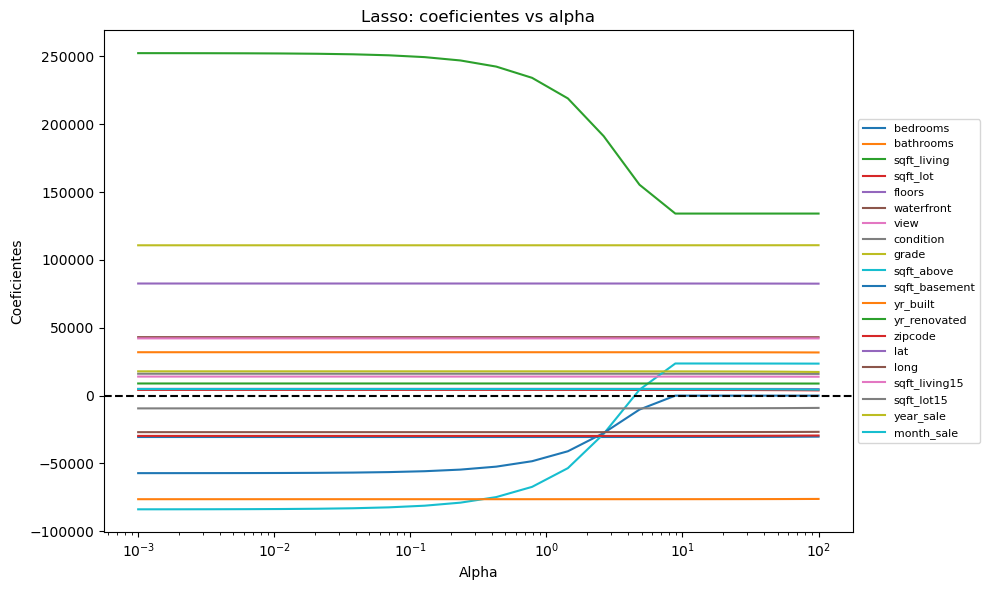

In [22]:
# graficar los coeficientes de Lasso 
coefs_array = np.array(coefs_lasso)                                 # convertir la lista de coeficientes de Lasso a un array de numpy, lo que facilita la visualización y el análisis de cómo cambian los coeficientes del modelo a medida que se ajusta la fuerza de la regularización con diferentes valores de alpha

print("shape coefs:", coefs_array.shape)                            # mostrar la forma del array de coeficientes de Lasso para verificar que tiene la dimensión esperada, donde el número de filas corresponde al número de valores de alpha evaluados y el número de columnas corresponde al número de características en el conjunto de entrenamiento
print("n alphas:", len(alphas))                                     # mostrar el número de valores de alpha evaluados para verificar que coincide con el número de filas en el array de coeficientes de Lasso, lo que confirma que se han guardado los coeficientes para cada valor de alpha evaluado
print("n columnas:", len(X_train_scaled.columns))                   # mostrar el número de columnas en el conjunto de entrenamiento escalado para verificar que coincide con el número de columnas en el array de coeficientes de Lasso, lo que confirma que se han guardado los coeficientes para cada característica en el conjunto de entrenamiento

plt.figure(figsize=(10, 6))                                         # crear una figura para la visualización de los coeficientes de Lasso, con un tamaño de 10 pulgadas de ancho y 6 pulgadas de alto, lo que proporciona suficiente espacio para mostrar claramente cómo cambian los coeficientes del modelo a medida que se ajusta la fuerza de la regularización con diferentes valores de alpha

for i, col in enumerate(X_train_scaled.columns):                    # iterar sobre cada columna en el conjunto de entrenamiento escalado utilizando enumerate para obtener tanto el índice como el nombre de la columna, lo que permite graficar los coeficientes de Lasso para cada característica en el conjunto de entrenamiento a medida que se ajusta la fuerza de la regularización con diferentes valores de alpha
    plt.plot(alphas, coefs_array[:, i], label=col)                  # graficar los coeficientes de Lasso para la característica actual utilizando plt.plot, donde el eje x representa los valores de alpha en escala logarítmica y el eje y representa los coeficientes correspondientes a esa característica para cada valor de alpha, lo que permite visualizar cómo cambian los coeficientes del modelo a medida que se ajusta la fuerza de la regularización con diferentes valores de alpha

plt.xscale('log')                                                   # establecer la escala del eje x a logarítmica para mejorar la visualización de los coeficientes de Lasso a medida que se ajusta la fuerza de la regularización con diferentes valores de alpha, lo que permite observar claramente cómo cambian los coeficientes del modelo en una amplia gama de valores de alpha
plt.axhline(0, color='black', linestyle='--')                       # agregar una línea horizontal en y=0 para facilitar la visualización de cuándo los coeficientes de Lasso se vuelven cero a medida que se ajusta la fuerza de la regularización con diferentes valores de alpha, lo que es especialmente útil para identificar las características que son seleccionadas o eliminadas por el modelo Lasso en función del valor de alpha
plt.title("Lasso: coeficientes vs alpha")                           # agregar un título a la gráfica para describir que se están visualizando los coeficientes del modelo Lasso en función de los valores de alpha, lo que proporciona contexto para interpretar la gráfica y entender cómo la fuerza de la regularización afecta los coeficientes del modelo
plt.xlabel("Alpha")                                                 # agregar una etiqueta al eje x para indicar que representa los valores de alpha, lo que proporciona contexto para interpretar la gráfica y entender cómo la fuerza de la regularización afecta los coeficientes del modelo Lasso a medida que se ajusta con diferentes valores de alpha
plt.ylabel("Coeficientes")                                          # agregar una etiqueta al eje y para indicar que representa los coeficientes del modelo Lasso, lo que proporciona contexto para interpretar la gráfica y entender cómo la fuerza de la regularización afecta los coeficientes del modelo Lasso a medida que se ajusta con diferentes valores de alpha
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=8)  # agregar una leyenda a la gráfica para identificar cada línea correspondiente a cada característica en el conjunto de entrenamiento, ubicándola fuera del área de la gráfica para mejorar la legibilidad, lo que permite interpretar fácilmente qué coeficiente corresponde a cada característica a medida que se ajusta la fuerza de la regularización con diferentes valores de alpha
plt.tight_layout()                                                  # ajustar el diseño de la gráfica para evitar que los elementos se superpongan o queden fuera del área visible, lo que mejora la legibilidad de la gráfica y permite visualizar claramente cómo cambian los coeficientes del modelo Lasso a medida que se ajusta la fuerza de la regularización con diferentes valores de alpha
plt.show()                                                          # mostrar la gráfica de los coeficientes de Lasso en función de los valores de alpha, lo que permite analizar visualmente cómo cambian los coeficientes del modelo a medida que se ajusta la fuerza de la regularización con diferentes valores de alpha, y entender qué características son seleccionadas o eliminadas por el modelo Lasso en función del valor de alpha

Se observa que, a medida que aumenta el parámetro de regularización (α) en el modelo Lasso, los coeficientes tienden a reducirse progresivamente, lo que indica una simplificación del modelo. Algunas variables pierden relevancia al acercarse sus coeficientes a cero, mientras que otras se mantienen, evidenciando su mayor importancia. Este comportamiento confirma que Lasso actúa como un mecanismo de selección de variables, favoreciendo modelos más simples y con mejor capacidad de generalización.

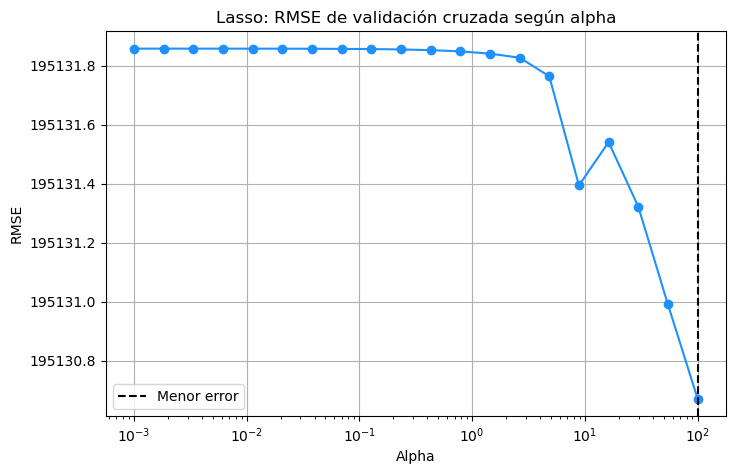

In [23]:
# Graficar el RMSE de validación cruzada para cada valor de alpha
plt.figure(figsize=(8, 5))                                                                          # crear una figura para la visualización del RMSE de validación cruzada para cada valor de alpha, con un tamaño de 8 pulgadas de ancho y 5 pulgadas de alto, lo que proporciona suficiente espacio para mostrar claramente cómo cambia el rendimiento del modelo Lasso a medida que se ajusta la fuerza de la regularización con diferentes valores de alpha    
plt.plot(alphas, cv_rmse_lasso, marker='o', color='dodgerblue')                                     # graficar el RMSE de validación cruzada para cada valor de alpha utilizando plt.plot, donde el eje x representa los valores de alpha en escala logarítmica y el eje y representa el RMSE correspondiente a cada valor de alpha, lo que permite visualizar cómo cambia el rendimiento del modelo Lasso a medida que se ajusta la fuerza de la regularización con diferentes valores de alpha
plt.axvline(alphas[np.argmin(cv_rmse_lasso)], color='black', linestyle='--', label='Menor error')   # agregar una línea vertical para indicar el valor de alpha que corresponde al menor RMSE de validación cruzada, lo que permite identificar visualmente cuál es el valor de alpha que proporciona el mejor rendimiento del modelo Lasso según la métrica de evaluación utilizada
plt.xscale('log')
plt.ticklabel_format(style='plain', axis='y')                                                       # establecer el formato de las etiquetas del eje y para que se muestren en formato plano en lugar de notación científica, lo que mejora la legibilidad de los valores de RMSE en la gráfica, especialmente cuando los valores son pequeños o grandes, y permite interpretar fácilmente el rendimiento del modelo Lasso a medida que se ajusta la fuerza de la regularización con diferentes valores de alpha
plt.gca().yaxis.get_major_formatter().set_useOffset(False)                                          # desactivar el uso de offset en las etiquetas del eje y para evitar que se muestren valores en notación científica con un desplazamiento, lo que mejora la legibilidad de los valores de RMSE en la gráfica, especialmente cuando los valores son pequeños o grandes, y permite interpretar fácilmente el rendimiento del modelo Lasso a medida que se ajusta la fuerza de la regularización con diferentes valores de alpha
plt.title("Lasso: RMSE de validación cruzada según alpha")                                          # agregar un título a la gráfica para describir que se está visualizando el RMSE de validación cruzada para el modelo Lasso en función de los valores de alpha, lo que proporciona contexto para interpretar la gráfica y entender cómo la fuerza de la regularización afecta el rendimiento del modelo Lasso a medida que se ajusta con diferentes valores de alpha
plt.xlabel("Alpha")                                                                                 # agregar una etiqueta al eje x para indicar que representa los valores de alpha, lo que proporciona contexto para interpretar la gráfica y entender cómo la fuerza de la regularización afecta el rendimiento del modelo Lasso a medida que se ajusta con diferentes valores de alpha
plt.ylabel("RMSE")                                                                                  # agregar una etiqueta al eje y para indicar que representa el RMSE de validación cruzada, lo que proporciona contexto para interpretar la gráfica y entender cómo la fuerza de la regularización afecta el rendimiento del modelo Lasso a medida que se ajusta con diferentes valores de alpha
plt.legend()                                                                                        # agregar una leyenda a la gráfica para identificar la línea que corresponde al valor de alpha con el menor RMSE de validación cruzada, lo que permite interpretar fácilmente cuál es el valor de alpha que proporciona el mejor rendimiento del modelo Lasso según la métrica de evaluación utilizada
plt.grid(True)                                                                                      # agregar una cuadrícula a la gráfica para mejorar la legibilidad y facilitar la interpretación de los valores de RMSE en función de los valores de alpha, lo que permite analizar visualmente cómo cambia el rendimiento del modelo Lasso a medida que se ajusta la fuerza de la regularización con diferentes valores de alpha
plt.show()                                                                                          # mostrar la gráfica del RMSE de validación cruzada para cada valor de alpha, lo que permite analizar visualmente cómo cambia el rendimiento del modelo Lasso a medida que se ajusta la fuerza de la regularización con diferentes valores de alpha, y entender cuál es el valor de alpha que proporciona el mejor rendimiento del modelo Lasso según la métrica de evaluación utilizada

El error (RMSE) disminuye a medida que aumenta el valor de α, alcanzando su mínimo en valores altos de regularización. Esto indica que un modelo más simple, con mayor penalización, generaliza mejor y evita el sobreajuste. En este caso, el mejor desempeño se logra con un α elevado, lo que confirma que reducir la complejidad del modelo mejora su capacidad predictiva.

El análisis del modelo Lasso muestra que el hiperparámetro α controla directamente la complejidad del modelo. A medida que α aumenta, los coeficientes de varias variables se reducen hasta volverse cercanos a cero, lo que implica una selección automática de características. Esto simplifica el modelo, eliminando variables poco relevantes.

Además, se observa que el error de validación (RMSE) disminuye para valores más altos de α, lo que indica una mejor capacidad de generalización y menor sobreajuste. En conjunto, Lasso logra un equilibrio entre simplicidad y rendimiento, identificando las variables más importantes mientras mejora el desempeño predictivo.

El modelo Lasso permite no solo optimizar el rendimiento, sino también reducir la dimensionalidad del problema, seleccionando automáticamente las variables más relevantes para la predicción del precio.

### 6. Utilizar métricas de evaluación de regresión, como el Error Cuadrático Medio (MSE), el Error Absoluto Medio (MAE) y el Coeficiente de Determinación (R²), para medir el rendimiento del modelo, realizar cuadro comparativo indicado en el punto 4, finaliza con una breve conclusión de a los resultados obtenidos.

In [24]:
# Entrenar el modelo de árbol de decisión con los hiperparámetros definidos para el modelo de árbol de decisión
modelo_final = DecisionTreeRegressor(       # Crear una instancia del modelo DecisionTreeRegressor con los hiperparámetros definidos para el modelo de árbol de decisión, lo que permite entrenar un modelo de árbol de decisión con una configuración específica que puede ayudar a mejorar su rendimiento y evitar el sobreajuste
    max_depth=10,                           # El hiperparámetro "max_depth" se establece en 10 para limitar la profundidad máxima del árbol de decisión, lo que ayuda a evitar el sobreajuste al limitar la complejidad del modelo y mejorar su capacidad de generalización a datos no vistos durante el entrenamiento
    min_samples_leaf=4,                     # El hiperparámetro "min_samples_leaf" se establece en 4 para especificar el número mínimo de muestras requeridas en un nodo hoja para que se realice una división, lo que ayuda a evitar el sobreajuste al prevenir la creación de nodos con pocos datos
    min_samples_split=10,                   # El hiperparámetro "min_samples_split" se establece en 10 para especificar el número mínimo de muestras requeridas para dividir un nodo interno, lo que ayuda a evitar el sobreajuste al prevenir la creación de divisiones con pocos datos
    random_state=42                         # El hiperparámetro "random_state" se establece en 42 para garantizar la reproducibilidad de los resultados del modelo, lo que permite obtener resultados consistentes en diferentes ejecuciones del modelo
)

modelo_final.fit(X_train_scaled, y_train)   # Entrenar el modelo de árbol de decisión utilizando el método fit con la matriz de características escalada para el conjunto de entrenamiento y la variable objetivo del conjunto de entrenamiento, lo que ajusta el modelo a los datos de entrenamiento con la configuración específica definida por los hiperparámetros para mejorar su rendimiento y capacidad de generalización a datos no vistos durante el entrenamiento

DecisionTreeRegressor(max_depth=10, min_samples_leaf=4, min_samples_split=10,
                      random_state=42)

Se entrenó un modelo de tipo DecisionTreeRegressor utilizando los hiperparámetros óptimos obtenidos previamente (profundidad máxima, número mínimo de muestras por nodo y criterio de división). Estos parámetros permiten controlar la complejidad del árbol, reduciendo el riesgo de sobreajuste y mejorando su capacidad de generalización. El modelo resultante queda preparado para realizar predicciones sobre nuevos datos, capturando relaciones no lineales entre las variables y el precio de las viviendas.

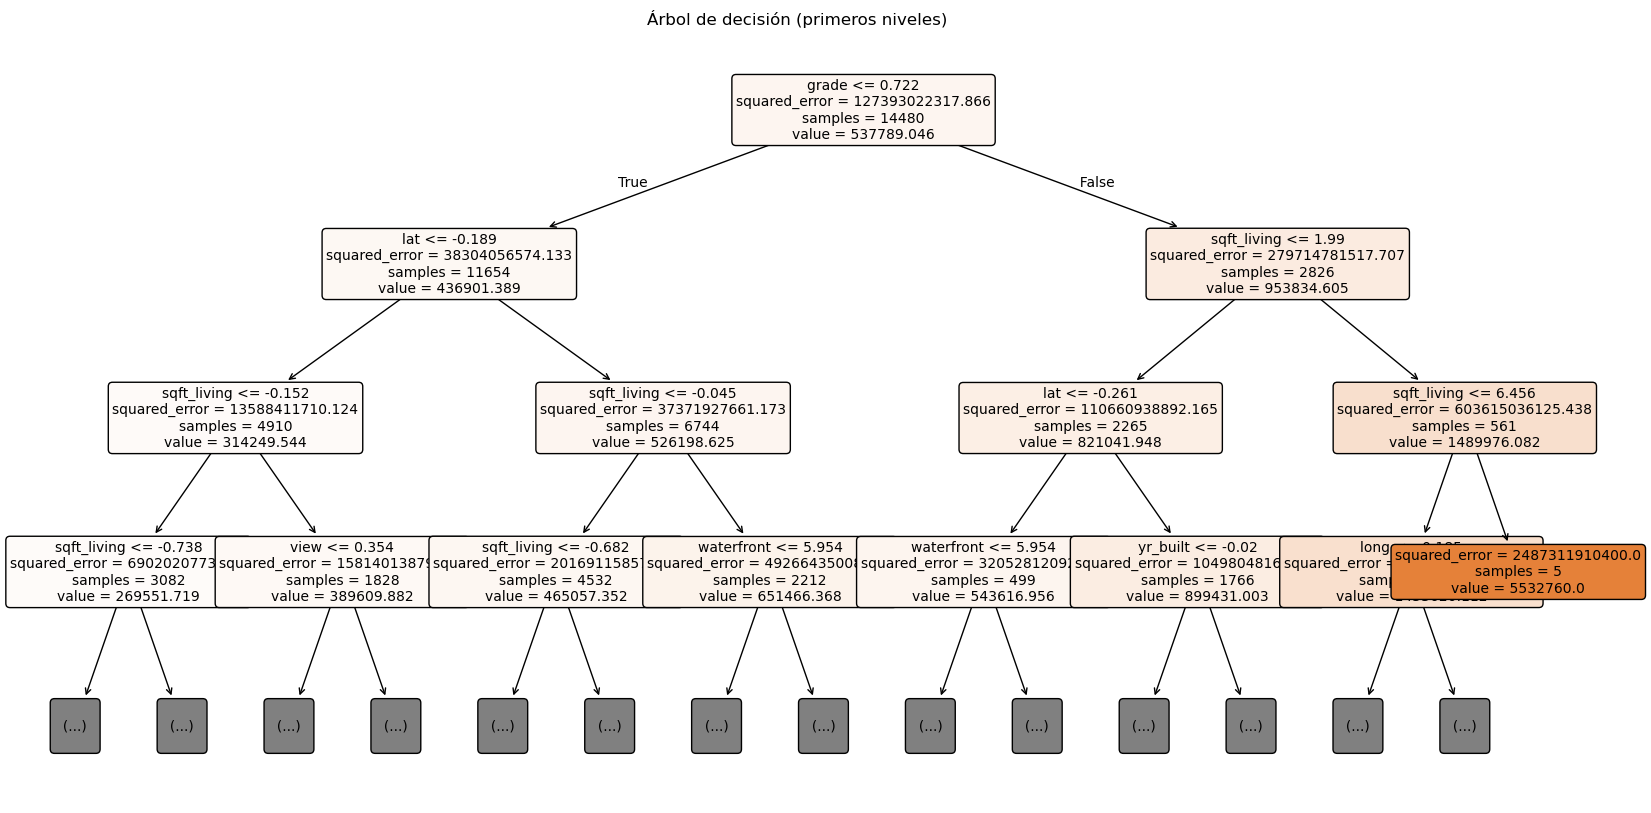

In [25]:
# Visualización del árbol de decisión utilizando plot_tree para mostrar los primeros niveles del árbol
plt.figure(figsize=(20,10))                         # Crear una figura para la visualización del árbol de decisión, con un tamaño de 20 pulgadas de ancho y 10 pulgadas de alto, lo que proporciona suficiente espacio para mostrar claramente los primeros niveles del árbol de decisión y facilitar la interpretación de su estructura y las decisiones tomadas en cada nodo
plot_tree(                                          # Utilizar la función plot_tree para visualizar el árbol de decisión entrenado, mostrando los primeros niveles del árbol para facilitar la interpretación de su estructura y las decisiones tomadas en cada nodo
    modelo_final,                                   # El modelo de árbol de decisión entrenado que se desea visualizar, lo que permite mostrar la estructura del árbol y las decisiones tomadas en cada nodo para entender cómo el modelo toma decisiones basadas en las características del conjunto de entrenamiento
    feature_names=X_train.columns,                  # Especificar los nombres de las características para que se muestren en la visualización del árbol de decisión
    filled=True,                                    # Rellenar los nodos con colores según el valor de la variable objetivo, lo que permite visualizar fácilmente la distribución de los datos en cada nodo
    rounded=True,                                   # Redondear las esquinas de los nodos para mejorar la apariencia de la visualización, lo que hace que el árbol sea más fácil de leer y comprender
    max_depth=3,                                    # Especificar la profundidad máxima del árbol a visualizar, lo que permite centrarse en los primeros niveles del árbol y facilitar la interpretación de sus decisiones
    fontsize=10                                     # Establecer el tamaño de la fuente para mejorar la legibilidad de los textos en la visualización del árbol
)

plt.title("Árbol de decisión (primeros niveles)")   # Agregar un título a la visualización del árbol de decisión para describir que se están mostrando los primeros niveles del árbol
plt.show()                                          # Mostrar la visualización del árbol de decisión

La visualización del árbol de decisión permite identificar las principales reglas utilizadas por el modelo para predecir el precio de las viviendas. En los primeros niveles se observan las variables más relevantes en la toma de decisiones, mientras que en niveles inferiores el modelo realiza divisiones más específicas. Esta representación facilita la interpretación del modelo, evidenciando cómo segmenta los datos en grupos con precios similares.

In [26]:
# Función para evaluar el modelo 
def evaluar_modelo_train_test(model, X_train, y_train, X_test, y_test): # Función para evaluar el modelo utilizando diferentes métricas de evaluación para el conjunto de entrenamiento y el conjunto de prueba, y devolver los resultados en un DataFrame
    y_train_pred = model.predict(X_train)                               # Utilizar el modelo para hacer predicciones sobre la matriz de características del conjunto de entrenamiento   
    y_test_pred = model.predict(X_test)                                 # Utilizar el modelo para hacer predicciones sobre la matriz de características del conjunto de prueba

    resultados = pd.DataFrame({                                         # Crear un DataFrame para almacenar los resultados de evaluación del modelo para el conjunto de entrenamiento y el conjunto de prueba, con las métricas de evaluación calculadas para cada conjunto
        "Dataset": ["Train", "Test"],                                   # Columna para identificar si los resultados corresponden al conjunto de entrenamiento o al conjunto de prueba
        "R2": [                                                         # Calcular el coeficiente de determinación R2 para el conjunto de entrenamiento y el conjunto de prueba utilizando las predicciones del modelo
            r2_score(y_train, y_train_pred),                            # Calcular el coeficiente de determinación R2 para el conjunto de entrenamiento utilizando las predicciones del modelo y la variable objetivo del conjunto de entrenamiento
            r2_score(y_test, y_test_pred)                               # Calcular el coeficiente de determinación R2 para el conjunto de prueba utilizando las predicciones del modelo y la variable objetivo del conjunto de prueba
        ],
        "MSE": [                                                        # Calcular el error cuadrático medio (MSE) para el conjunto de entrenamiento y el conjunto de prueba utilizando las predicciones del modelo
            mean_squared_error(y_train, y_train_pred),                  # Calcular el error cuadrático medio (MSE) para el conjunto de entrenamiento utilizando las predicciones del modelo y la variable objetivo del conjunto de entrenamiento
            mean_squared_error(y_test, y_test_pred)                     # Calcular el error cuadrático medio (MSE) para el conjunto de prueba utilizando las predicciones del modelo y la variable objetivo del conjunto de prueba
        ],
        "RMSE": [                                                       # Calcular la raíz del error cuadrático medio (RMSE) para el conjunto de entrenamiento y el conjunto de prueba utilizando las predicciones del modelo
            np.sqrt(mean_squared_error(y_train, y_train_pred)),         # Calcular la raíz del error cuadrático medio (RMSE) para el conjunto de entrenamiento utilizando las predicciones del modelo y la variable objetivo del conjunto de entrenamiento
            np.sqrt(mean_squared_error(y_test, y_test_pred))            # Calcular la raíz del error cuadrático medio (RMSE) para el conjunto de prueba utilizando las predicciones del modelo y la variable objetivo del conjunto de prueba
        ],
        "MAE": [                                                        # Calcular el error absoluto medio (MAE) para el conjunto de entrenamiento y el conjunto de prueba utilizando las predicciones del modelo
            mean_absolute_error(y_train, y_train_pred),                 # Calcular el error absoluto medio (MAE) para el conjunto de entrenamiento utilizando las predicciones del modelo y la variable objetivo del conjunto de entrenamiento
            mean_absolute_error(y_test, y_test_pred)                    # Calcular el error absoluto medio (MAE) para el conjunto de prueba utilizando las predicciones del modelo y la variable objetivo del conjunto de prueba
        ],
        "MAPE": [                                                       # Calcular el error porcentual absoluto medio (MAPE) para el conjunto de entrenamiento y el conjunto de prueba utilizando las predicciones del modelo
            mean_absolute_percentage_error(y_train, y_train_pred),      # Calcular el error porcentual absoluto medio (MAPE) para el conjunto de entrenamiento utilizando las predicciones del modelo y la variable objetivo del conjunto de entrenamiento
            mean_absolute_percentage_error(y_test, y_test_pred)         # Calcular el error porcentual absoluto medio (MAPE) para el conjunto de prueba utilizando las predicciones del modelo y la variable objetivo del conjunto de prueba
        ]
    })

    return resultados                                                   # Devolver el DataFrame con los resultados de evaluación del modelo para el conjunto de entrenamiento y el conjunto de prueba   

In [27]:
# Evaluar el modelo final 
resultado_final = evaluar_modelo_train_test(    # Llamar a la función para evaluar el modelo utilizando diferentes métricas de evaluación para el conjunto de entrenamiento y el conjunto de prueba, y devolver los resultados en un DataFrame
    modelo_final,                               # El modelo de árbol de decisión entrenado que se desea evaluar
    X_train_scaled, y_train,                    # La matriz de características escalada para el conjunto de entrenamiento y la variable objetivo del conjunto de entrenamiento, que se utilizarán para evaluar el rendimiento del modelo en el conjunto de entrenamiento
    X_test_scaled, y_test                       # La matriz de características escalada para el conjunto de prueba y la variable objetivo del conjunto de prueba, que se utilizarán para evaluar el rendimiento del modelo en el conjunto de prueba
)

display(resultado_final)                        # Mostrar el DataFrame con los resultados de evaluación del modelo para el conjunto de entrenamiento y el conjunto de prueba

,Dataset,R2,MSE,RMSE,MAE,MAPE
0,Train,0.895287,1.333973e+10,115497.732482,70842.618928,0.136994
1,Test,0.798089,3.023245e+10,173874.811502,92034.894885,0.167032


La comparación entre los conjuntos de entrenamiento y prueba muestra que el modelo obtiene un mejor desempeño en train que en test, evidenciando cierto grado de sobreajuste. Sin embargo, la diferencia en las métricas no es excesiva, lo que indica que el modelo mantiene una adecuada capacidad de generalización. En particular, los valores de error (RMSE, MAE y MAPE) en test siguen siendo razonables, confirmando que el modelo es capaz de realizar predicciones útiles sobre datos no vistos.

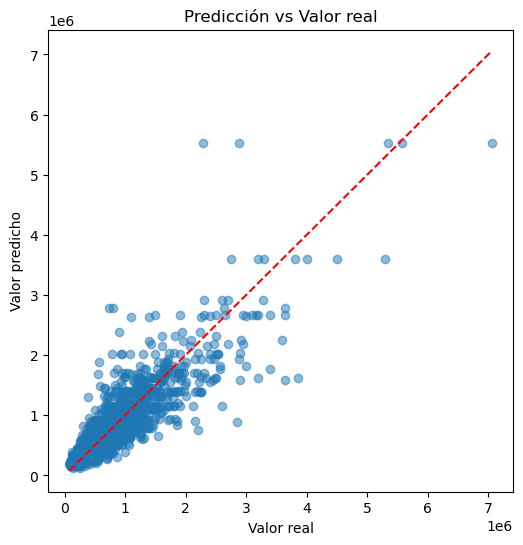

In [28]:
# Visualización de la predicción vs valor real para el modelo final
y_pred = modelo_final.predict(X_test_scaled)                                # Utilizar el modelo de árbol de decisión entrenado para hacer predicciones sobre la matriz de características escalada para el conjunto de prueba, lo que permite comparar las predicciones del modelo con los valores reales de la variable objetivo en el conjunto de prueba para evaluar visualmente el rendimiento del modelo
plt.figure(figsize=(6,6))                                                   # Crear una figura para la visualización de la predicción vs valor real, con un tamaño de 6 pulgadas de ancho y 6 pulgadas de alto, lo que proporciona un espacio cuadrado para mostrar claramente la relación entre las predicciones del modelo y los valores reales de la variable objetivo en el conjunto de prueba
plt.scatter(y_test, y_pred, alpha=0.5)                                      # Crear un gráfico de dispersión utilizando plt.scatter para mostrar la relación entre los valores reales de la variable objetivo en el conjunto de prueba (eje x) y las predicciones del modelo (eje y), donde alpha se establece en 0.5 para hacer que los puntos sean semitransparentes
plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()], 'r--')  # Agregar una línea diagonal utilizando plt.plot para indicar la línea de igualdad entre los valores reales y las predicciones del modelo, lo que permite visualizar fácilmente qué tan cerca están las predicciones del modelo de los valores reales en el gráfico de dispersión                                
plt.xlabel("Valor real")                                                    # Agregar una etiqueta al eje x para indicar que representa los valores reales de la variable objetivo en el conjunto de prueba, lo que proporciona contexto para interpretar la gráfica y entender la relación entre las predicciones del modelo y los valores reales
plt.ylabel("Valor predicho")                                                # Agregar una etiqueta al eje y para indicar que representa las predicciones del modelo, lo que proporciona contexto para interpretar la gráfica y entender la relación entre las predicciones del modelo y los valores reales
plt.title("Predicción vs Valor real")                                       # Agregar un título a la gráfica para describir que se está visualizando la relación entre las predicciones del modelo y los valores reales de la variable objetivo en el conjunto de prueba
plt.show()                                                                  # Mostrar la gráfica de predicción vs valor real para evaluar visualmente el rendimiento del modelo en el conjunto de prueba, lo que permite analizar la relación entre las predicciones del modelo y los valores reales de la variable objetivo en el conjunto de prueba, y entender qué tan cerca están las predicciones del modelo de los valores reales.

El gráfico muestra una relación positiva entre los valores reales y predichos, lo que indica que el modelo captura adecuadamente la tendencia general de los precios. Sin embargo, se observa dispersión alrededor de la línea ideal, especialmente en valores altos, lo que sugiere que el modelo tiene mayor error en propiedades de mayor precio. En general, el modelo presenta un buen desempeño, aunque con menor precisión en los extremos.

### Conclusion
En este proyecto se desarrolló un modelo de predicción del precio de viviendas a partir de sus características, realizando un análisis exploratorio previo para comprender la distribución de los datos y las relaciones entre variables. Se identificó que factores como el tamaño de la propiedad, la calidad de construcción y ciertas características estructurales presentan una alta correlación con el precio, lo que resulta coherente con el comportamiento esperado del mercado inmobiliario.

Posteriormente, se entrenaron distintos modelos de regresión, incluyendo técnicas con regularización y árboles de decisión, evaluando su desempeño mediante métricas como R², RMSE, MAE y MAPE. Los resultados evidenciaron que el modelo de árbol de decisión obtuvo el mejor desempeño, logrando capturar relaciones no lineales presentes en los datos y mejorando la capacidad predictiva respecto a los modelos lineales.

Además, se analizó el comportamiento del modelo en los conjuntos de entrenamiento y prueba, observándose una ligera diferencia que indica cierto grado de sobreajuste, aunque manteniendo una adecuada capacidad de generalización. La visualización de predicciones y del árbol permitió interpretar el funcionamiento del modelo y comprender cómo las variables influyen en la estimación del precio.

En conjunto, el trabajo permite concluir que es posible construir modelos predictivos efectivos para este tipo de problemas, siempre considerando la calidad de los datos, la presencia de valores atípicos y la correcta selección y evaluación de los modelos.